# Occupation erasure via top-k selection

Erase **occupation** from off-the-shelf embeddings using **top-k greedy question selection**:
an LLM expands the concept into a pool of yes/no questions, JEV scores them, and `select_k` greedily
keeps the few that best reconstruct the pool. We then erase with just those and measure held-out
**occupation** accuracy before vs. after.

Runs offline from the bundled cache (`USE_CACHE=True`); set it `False` to call the APIs live.

In [1]:
import os, sys, json, hashlib, logging
from pathlib import Path
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize

logging.basicConfig(level=logging.INFO, format='%(levelname)s %(name)s: %(message)s')
for _n in ('httpx', 'httpcore', 'openai', 'openai._base_client'):
    logging.getLogger(_n).setLevel(logging.WARNING)       # silence OpenAI/OpenRouter request logs

def _root(s):
    for q in [Path(s).resolve(), *Path(s).resolve().parents]:
        if (q/'pyproject.toml').exists() and (q/'src'/'jevu').exists():
            return q
    return Path(s).resolve()
ROOT = _root(os.getcwd())
if str(ROOT/'src') not in sys.path: sys.path.insert(0, str(ROOT/'src'))
from jevu import ConceptScrubber

_envf = ROOT/'.env'
if _envf.exists():
    for _l in _envf.read_text().splitlines():
        _l = _l.strip()
        if _l and not _l.startswith('#') and '=' in _l:
            _k, _v = _l.split('=', 1); os.environ.setdefault(_k.strip(), _v.strip().strip('\'"'))

USE_CACHE = False        # offline from the bundled cache; set False to call APIs live
CACHE = (ROOT/'examples'/'.jev_debias_cache') if USE_CACHE else None
if CACHE: CACHE.mkdir(parents=True, exist_ok=True)
SEED, N, DENSE_MODEL = 2026, 900, 'text-embedding-3-small'
DATASET, CONFIG, SPLIT = 'LabHC/bias_in_bios', 'default', 'test'
HF_ROWS = 'https://datasets-server.huggingface.co/rows'
def dg(x): return hashlib.sha256(json.dumps(x, sort_keys=True, ensure_ascii=False).encode()).hexdigest()
def sj(p, x): p.write_text(json.dumps(x, ensure_ascii=False))
print('caching:', bool(CACHE))

caching: False


## 1. Data: real bios + off-the-shelf embeddings

In [2]:
def hf_page(off, length=100):
    p = (CACHE/f'bios_{SPLIT}_{off}_{length}.json') if CACHE else None
    if p and p.exists(): return json.loads(p.read_text())
    import httpx
    r = httpx.get(HF_ROWS, params={'dataset': DATASET, 'config': CONFIG, 'split': SPLIT, 'offset': int(off), 'length': int(length)}, timeout=60); r.raise_for_status()
    d = r.json();
    if p: sj(p, d)
    return d

def load_bios(n, seed):
    p = (CACHE/f'bios_sample_{n}_{seed}.json') if CACHE else None
    if p and p.exists(): return json.loads(p.read_text())['rows']
    total = hf_page(0, 1)['num_rows_total']; rng = np.random.default_rng(seed)
    rows = []
    for off in rng.permutation(np.arange(0, total, 100)):
        for it in hf_page(int(off), 100)['rows']:
            r = it['row']; t = str(r['hard_text'] or '').strip()
            if t: rows.append({'text': t[:700], 'prof': int(r['profession']), 'gender': int(r['gender'])})
        if len(rows) >= n: break
    rng.shuffle(rows); rows = rows[:n]
    if p: sj(p, {'rows': rows})
    return rows

def embed_dense(texts):
    p = (CACHE/f'dense_{dg({"m": DENSE_MODEL, "t": texts})}.json') if CACHE else None
    if p and p.exists(): return np.asarray(json.loads(p.read_text()), dtype=float)
    from openai import OpenAI
    cl = OpenAI(timeout=90); v = []
    for s in range(0, len(texts), 200):
        v.extend(x.embedding for x in cl.embeddings.create(model=DENSE_MODEL, input=texts[s:s+200]).data)
    v = np.asarray(v, dtype=float)
    if p: sj(p, v.tolist())
    return v

rows = load_bios(N, SEED)
texts = [r['text'] for r in rows]
prof = np.array([r['prof'] for r in rows]); gender = np.array([r['gender'] for r in rows])
X = normalize(embed_dense(texts))
tr, te = train_test_split(np.arange(N), test_size=0.3, random_state=SEED, stratify=gender)
print(len(texts), 'bios |', len(np.unique(prof)), 'occupations | embeddings', X.shape)

INFO httpx2: HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


INFO httpx2: HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


INFO httpx2: HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


INFO httpx2: HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


INFO httpx2: HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


900 bios | 28 occupations | embeddings (900, 1536)


## 2. The data split (occupations × gender)

The corpus is highly imbalanced across the 28 occupations, and several are gender-skewed — which is exactly what makes a 28-way probe need many rows and what gender-biased retrieval keys on.

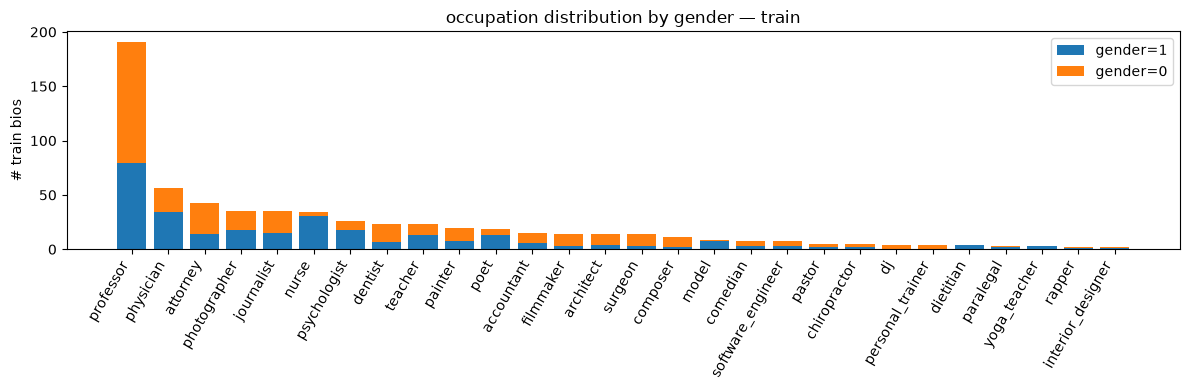

In [3]:
import matplotlib.pyplot as plt
PROFESSIONS = ['accountant','architect','attorney','chiropractor','comedian','composer','dentist','dietitian','dj','filmmaker','interior_designer','journalist','model','nurse','painter','paralegal','pastor','personal_trainer','photographer','physician','poet','professor','psychologist','rapper','software_engineer','surgeon','teacher','yoga_teacher']
vals = np.unique(prof[tr])
fem = np.array([np.sum((prof[tr] == v) & (gender[tr] == 1)) for v in vals])
mal = np.array([np.sum((prof[tr] == v) & (gender[tr] == 0)) for v in vals])
order = np.argsort(-(fem + mal))
plt.figure(figsize=(12, 4))
plt.bar(range(len(vals)), fem[order], label='gender=1')
plt.bar(range(len(vals)), mal[order], bottom=fem[order], label='gender=0')
plt.xticks(range(len(vals)), [PROFESSIONS[v] for v in vals[order]], rotation=60, ha='right')
plt.ylabel('# train bios'); plt.legend(); plt.title('occupation distribution by gender — train')
plt.tight_layout(); plt.show()

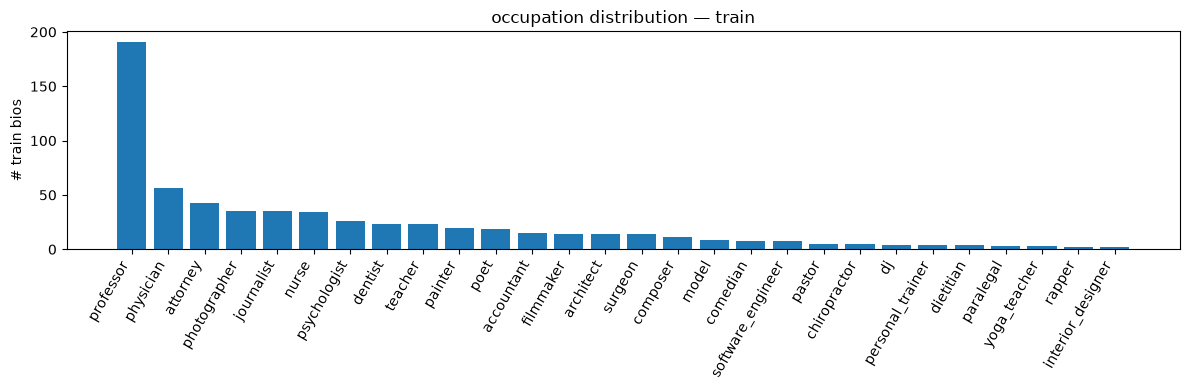

In [4]:
PROFESSIONS = [
    'accountant', 'architect', 'attorney', 'chiropractor', 'comedian', 'composer',
    'dentist', 'dietitian', 'dj', 'filmmaker', 'interior_designer', 'journalist',
    'model', 'nurse', 'painter', 'paralegal', 'pastor', 'personal_trainer',
    'photographer', 'physician', 'poet', 'professor', 'psychologist', 'rapper',
    'software_engineer', 'surgeon', 'teacher', 'yoga_teacher',
]   # index == the `prof` integer

names = [PROFESSIONS[i] for i in prof]          # per-bio occupation name
PROFESSIONS[prof[0]]                             # one bio's occupation

import matplotlib.pyplot as plt, numpy as np
vals, counts = np.unique(prof[tr], return_counts=True)
order = np.argsort(-counts)
plt.figure(figsize=(12, 4))
plt.bar(range(len(vals)), counts[order])
plt.xticks(range(len(vals)), [PROFESSIONS[v] for v in vals[order]], rotation=60, ha='right')
plt.ylabel('# train bios'); plt.title('occupation distribution — train')
plt.tight_layout(); plt.show()

## 3. The pipeline: 15 diverse questions → greedy select k=3 → erase

The canonical `jevu` run for a many-valued identity: expand `occupation` into a **pool of 15 diverse, fine-grained questions** (one specific job each; `temperature=0`, so it is deterministic and reproducible), **greedily select the k=3** that best reconstruct the pool (logged as `INFO jevu.scrubber: greedy select …`, stored in `selected_questions_`), and erase just those with LEACE. Selection runs on a **250-row sample**; only the kept questions are scored on the full train split.

We report **two** metrics because they disagree, and the disagreement is the point: **top-1 accuracy** (is the occupation the argmax prediction) and **one-vs-rest AUC** (is the occupation signal still *linearly recoverable* at all, independent of class priors).

In [5]:
CONCEPT = 'occupation'
from sklearn.metrics import roc_auc_score
from jevu import LeaceEraser

def metrics(A, B):
    """Top-1 28-way accuracy, and mean one-vs-rest AUC (base-rate robust)."""
    clf = LogisticRegression(max_iter=3000).fit(A, prof[tr])
    pred, P = clf.predict(B), clf.predict_proba(B)
    auc = [roc_auc_score((prof[te] == p).astype(int), P[:, j])
           for j, p in enumerate(clf.classes_) if 0 < (prof[te] == p).sum() < len(prof[te])]
    return (pred == prof[te]).mean(), float(np.mean(auc))

# The pipeline: expand 'occupation' -> 15 diverse questions -> greedy select k=3 -> LEACE erase.
scr = ConceptScrubber(method='leace', expand=True, concept=CONCEPT, n_questions=15,
                      select_k=3, select_sample=250,
                      cache_dir=str(CACHE) if CACHE else None, max_workers=24)
scr.fit(embeddings=X[tr], texts=[texts[i] for i in tr])      # select on 250, fit eraser on full train
Xd = scr.transform(X)
print('pool of', len(scr.concept_questions_), 'questions -> greedy kept k=3:')
for q in scr.selected_questions_: print('   -', q)

# reference ceiling: erase with the TRUE one-hot occupation labels (the correct full-rank target)
Xc = LeaceEraser().fit(X[tr], np.eye(28)[prof[tr]]).transform(X)

print(f'\n{"":<20}{"accuracy":>10}{"occ AUC":>9}')
for name, A, B in [('before', X[tr], X[te]), ('erased (k=3)', Xd[tr], Xd[te]),
                   ('true-label ceiling', Xc[tr], Xc[te])]:
    a, u = metrics(A, B); print(f'{name:<20}{a:>10.3f}{u:>9.3f}')
print('\naccuracy = top-1 (drops hard); AUC = signal still recoverable (barely moves at k=3 -- see §6)')

INFO httpx2: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


INFO jevu.concepts: expanded concept 'occupation' into 15 questions: ['Does the text describe a teacher?', 'Does the text describe an author?', 'Does the text describe a lawyer?', 'Does the text describe a researcher?', 'Does the text describe a nurse?', 'Does the text describe a journalist?', 'Does the text describe a photographer?', 'Does the text describe a physician?', 'Does the text describe a professor?', 'Does the text describe a software engineer?', 'Does the text describe a dentist?', 'Does the text describe a psychologist?', 'Does the text describe a community service worker?', 'Does the text describe a physicist?', 'Does the text describe a sociologist?']


INFO jevu.scrubber: selecting 3/15 questions on a 250-row sample


INFO jevu.concepts: scoring 250 texts x 15 questions = 3750 cells (0 cached, 3750 to fetch)


JEV x15: occupation:   0%|          | 0/3750 [00:00<?, ?it/s]

...

INFO jevu.erasers: LEACE erased concept (d=1536, k=3)


pool of 15 questions -> greedy kept k=3:
   - Does the text describe a professor?
   - Does the text describe a physician?
   - Does the text describe a researcher?


INFO jevu.erasers: LEACE erased concept (d=1536, k=28)



                      accuracy  occ AUC
before                   0.648    0.978
erased (k=3)             0.404    0.947


true-label ceiling       0.304    0.519

accuracy = top-1 (drops hard); AUC = signal still recoverable (barely moves at k=3 -- see §6)


## 4. PCA: embeddings before vs. after erasure

Same 2-D PCA axes for both panels (fit on the originals). Colored by the top occupations: the clusters that separate professions **before** collapse/merge **after** erasing occupation.

INFO httpx2: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


INFO jevu.concepts: expanded concept 'occupation' into 15 questions: ['Does the text describe a teacher?', 'Does the text describe an author?', 'Does the text describe a lawyer?', 'Does the text describe a researcher?', 'Does the text describe a nurse?', 'Does the text describe a journalist?', 'Does the text describe a photographer?', 'Does the text describe a physician?', 'Does the text describe a professor?', 'Does the text describe a software engineer?', 'Does the text describe a dentist?', 'Does the text describe a psychologist?', 'Does the text describe a community service worker?', 'Does the text describe a physicist?', 'Does the text describe a sociologist?']


INFO jevu.scrubber: selecting 3/15 questions on a 250-row sample


INFO jevu.concepts: scoring 250 texts x 15 questions = 3750 cells (0 cached, 3750 to fetch)


JEV x15: occupation:   0%|          | 0/3750 [00:00<?, ?it/s]

...

INFO jevu.scrubber: greedy select 3/3: 'Does the text describe a researcher?' (reconstruction residual 9.876)


INFO jevu.scrubber: kept 3/15 questions: ['Does the text describe a professor?', 'Does the text describe a physician?', 'Does the text describe a researcher?']


INFO jevu.concepts: scoring 630 texts x 3 questions = 1890 cells (0 cached, 1890 to fetch)


JEV x3: occupation:   0%|          | 0/1890 [00:00<?, ?it/s]

INFO jevu.erasers: LEACE erased concept (d=1536, k=3)


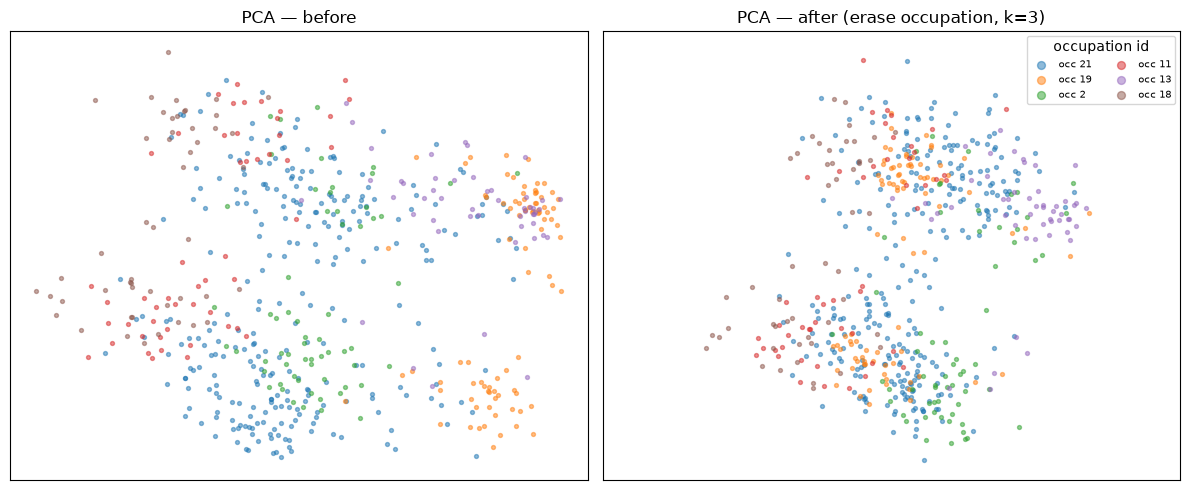

In [6]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
scr_v = ConceptScrubber(method='leace', expand=True, concept=CONCEPT, n_questions=15,
                        select_k=3, select_sample=250, cache_dir=str(CACHE) if CACHE else None, max_workers=24)
scr_v.fit(embeddings=X[tr], texts=[texts[i] for i in tr]); Xd = scr_v.transform(X)
pca = PCA(n_components=2, random_state=SEED).fit(X)
PB, PA = pca.transform(X), pca.transform(Xd)
vals, counts = np.unique(prof, return_counts=True); top = vals[np.argsort(-counts)[:6]]
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
for axi, (P, ttl) in zip(ax, [(PB, 'before'), (PA, 'after (erase occupation, k=3)')]):
    for t in top:
        m = prof == t; axi.scatter(P[m, 0], P[m, 1], s=8, alpha=0.5, label=f'occ {t}')
    axi.set_title(f'PCA — {ttl}'); axi.set_xticks([]); axi.set_yticks([])
ax[1].legend(fontsize=7, ncol=2, markerscale=2, title='occupation id')
plt.tight_layout(); plt.show()

## 5. Why it works: which professions the selected questions cover

Each selected question fires (high JEV score) on a cluster of occupations. The heatmap shows the mean score of each of the 3 selected questions per occupation; the bar below is each occupation's **best** coverage. Occupations **covered** by some selected question (green) lose their direction and get erased; **uncovered** ones (red) survive — which is why a small k only partially drops occupation accuracy.

INFO jevu.concepts: scoring 630 texts x 3 questions = 1890 cells (0 cached, 1890 to fetch)


JEV x3: occupation:   0%|          | 0/1890 [00:00<?, ?it/s]

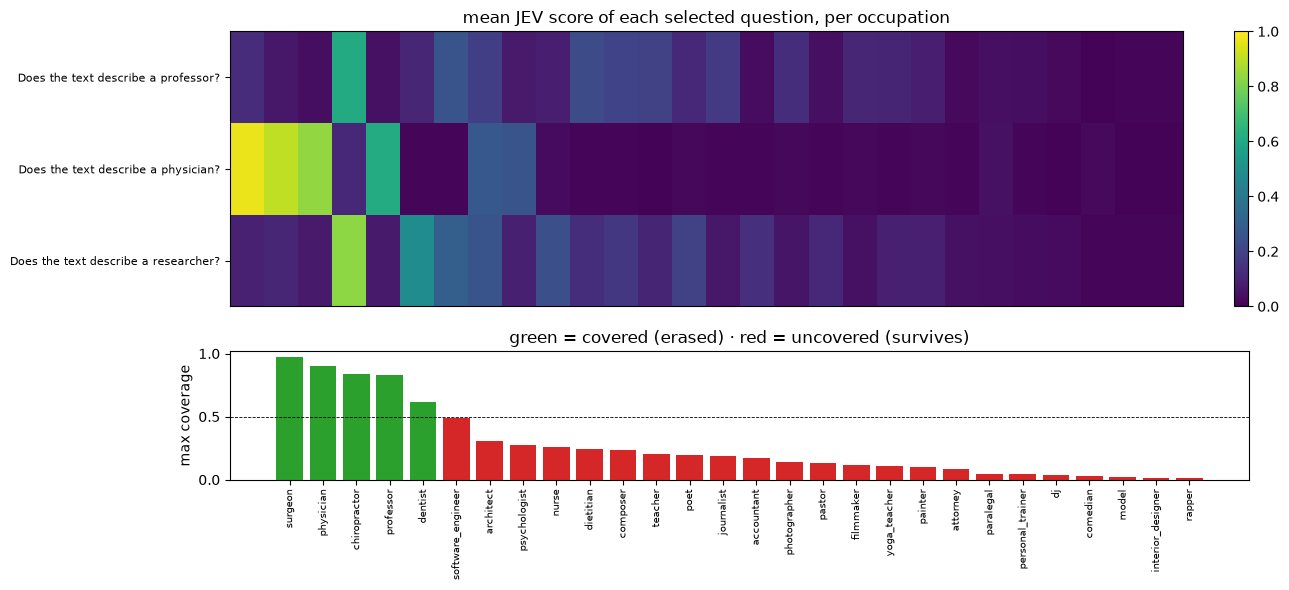

In [7]:
sel = scr_v.selected_questions_
Zsel = scr_v._labeler_().score_questions(sel, [texts[i] for i in tr])   # (630, k), cached
ptr = prof[tr]; profs = np.unique(ptr)
cov = np.array([[Zsel[ptr == p, j].mean() for p in profs] for j in range(len(sel))])  # (k, n_prof)
col = np.argsort(-cov.max(axis=0))                                    # occupations by best coverage
fig, ax = plt.subplots(2, 1, figsize=(13, 6), gridspec_kw={'height_ratios': [len(sel), 1.4]})
im = ax[0].imshow(cov[:, col], aspect='auto', cmap='viridis', vmin=0, vmax=1)
ax[0].set_yticks(range(len(sel))); ax[0].set_yticklabels([q[:48] for q in sel], fontsize=8)
ax[0].set_xticks([]); ax[0].set_title('mean JEV score of each selected question, per occupation')
fig.colorbar(im, ax=ax[0], fraction=0.015)
best = cov.max(axis=0)[col]
ax[1].bar(range(len(profs)), best, color=['tab:green' if b >= 0.5 else 'tab:red' for b in best])
ax[1].axhline(0.5, color='k', lw=0.6, ls='--')
ax[1].set_xticks(range(len(profs))); ax[1].set_xticklabels([PROFESSIONS[p] for p in profs[col]], rotation=90, fontsize=7)
ax[1].set_ylabel('max coverage'); ax[1].set_title('green = covered (erased) · red = uncovered (survives)')
plt.tight_layout(); plt.show()

## 6. Can we still *extract* occupation afterward? Dominant vs. minority professions

Section 5 showed the `k=3` questions mostly cover the **dominant** (most-represented) professions. So
a sharper test of the erasure: split the 28 professions into the **head** (the few that make up ~75%
of the data) and the **tail** (the rest), and ask a probe — *can you still recover each profession's
occupation after erasure?* We measure with **one-vs-rest AUC** (base-rate robust, unlike raw accuracy
which a majority-class default would inflate).

dominant/head:  9 professions, 466/630 train rows
minority/tail: 19 professions, 164/630 train rows



INFO httpx2: HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


INFO jevu.concepts: expanded concept 'occupation' into 15 questions: ['Does the text describe a teacher?', 'Does the text describe an author?', 'Does the text describe a lawyer?', 'Does the text describe a researcher?', 'Does the text describe a nurse?', 'Does the text describe a journalist?', 'Does the text describe a photographer?', 'Does the text describe a physician?', 'Does the text describe a professor?', 'Does the text describe a software engineer?', 'Does the text describe a dentist?', 'Does the text describe a psychologist?', 'Does the text describe a community service worker?', 'Does the text describe a physicist?', 'Does the text describe a sociologist?']


INFO jevu.scrubber: selecting 3/15 questions on a 250-row sample


INFO jevu.concepts: scoring 250 texts x 15 questions = 3750 cells (0 cached, 3750 to fetch)


...

JEV x15: occupation:   0%|          | 0/9450 [00:00<?, ?it/s]

INFO jevu.erasers: LEACE erased concept (d=1536, k=15)


INFO jevu.erasers: LEACE erased concept (d=1536, k=28)


erase         |   dominant / head    |   minority / tail    | predicts
              |       acc    OvR-AUC |       acc    OvR-AUC | majority
------------------------------------------------------------------------------
before        |     0.813      0.972 |     0.149      0.981 |    51%
k=3           |     0.537      0.902 |     0.000      0.973 |    89%


k=15          |     0.404      0.582 |     0.000      0.912 |   100%
true labels   |     0.404      0.470 |     0.000      0.546 |   100%


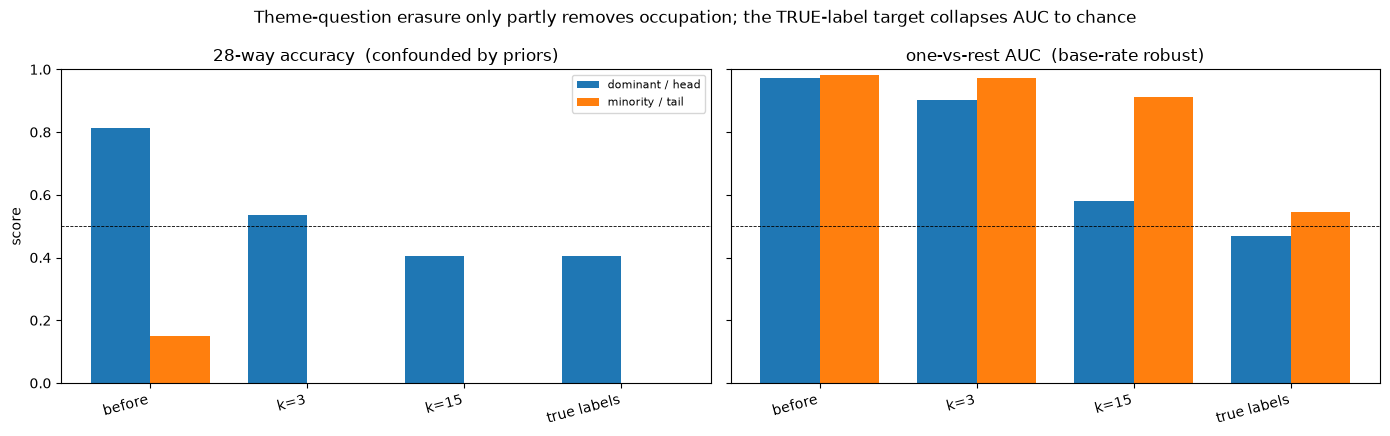

In [8]:
# Can a probe still EXTRACT occupation after erasure? And is the erasure even complete?
# Two metrics (they disagree -- that IS the lesson):
#   * 28-way accuracy : intuitive, but confounded by priors (argmax favours the majority class)
#   * one-vs-rest AUC : base-rate robust -- measures whether the SIGNAL survives, ignoring priors
# Plus a reference: erase the TRUE one-hot occupation (the correct, full-rank target) to see the ceiling.
from sklearn.metrics import roc_auc_score
from jevu import LeaceEraser
ptr, pte = prof[tr], prof[te]; profs = np.unique(ptr)
counts = np.array([(ptr == p).sum() for p in profs]); order = np.argsort(-counts)
cum = np.cumsum(counts[order]) / counts.sum()
dominant = set(profs[order[cum <= 0.75]]); minority = set(profs[order[cum > 0.75]])
maj = profs[order[0]]
print(f'dominant/head: {len(dominant):>2} professions, {counts[order][cum<=0.75].sum()}/{counts.sum()} train rows')
print(f'minority/tail: {len(minority):>2} professions, {counts[order][cum>0.75].sum()}/{counts.sum()} train rows\n')

def metrics(A, B):
    clf = LogisticRegression(max_iter=3000).fit(A, ptr)
    pred, P, cls = clf.predict(B), clf.predict_proba(B), clf.classes_
    auc = {p: roc_auc_score((pte == p).astype(int), P[:, j])
           for j, p in enumerate(cls) if 0 < (pte == p).sum() < len(pte)}
    grp = lambda g: ((pred[np.isin(pte, list(g))] == pte[np.isin(pte, list(g))]).mean(),
                     float(np.mean([auc[p] for p in g if p in auc])))
    return grp(dominant), grp(minority), (pred == maj).mean()

configs = {'before': X}
for k in [3, 15]:
    scr = ConceptScrubber(method='leace', expand=True, concept=CONCEPT, n_questions=15,
                          select_k=k, select_sample=250, cache_dir=str(CACHE) if CACHE else None, max_workers=24)
    scr.fit(embeddings=X[tr], texts=[texts[i] for i in tr]); configs[f'k={k}'] = scr.transform(X)
# reference: erase the TRUE 28-way one-hot occupation (rank ~27 -> the full-rank correct target)
er = LeaceEraser().fit(X[tr], np.eye(28)[ptr]); configs['true labels'] = np.vstack([er.transform(X)])

rows_m = {}
print(f'{"erase":<14}| {"dominant / head":^20} | {"minority / tail":^20} | predicts')
print(f'{"":<14}| {"acc":>9}{"OvR-AUC":>11} | {"acc":>9}{"OvR-AUC":>11} | majority')
print('-' * 78)
for name, Xc in configs.items():
    (da, dauc), (ma, mauc), majshare = metrics(Xc[tr], Xc[te]); rows_m[name] = (da, dauc, ma, mauc)
    print(f'{name:<14}| {da:>9.3f}{dauc:>11.3f} | {ma:>9.3f}{mauc:>11.3f} | {majshare:>6.0%}')

labels = list(configs); x = np.arange(len(labels)); w = 0.38
fig, axes = plt.subplots(1, 2, figsize=(14, 4.4), sharey=True)
for ax, (i0, i1, title) in zip(axes, [(0, 2, '28-way accuracy  (confounded by priors)'),
                                       (1, 3, 'one-vs-rest AUC  (base-rate robust)')]):
    ax.bar(x - w/2, [rows_m[l][i0] for l in labels], w, label='dominant / head', color='tab:blue')
    ax.bar(x + w/2, [rows_m[l][i1] for l in labels], w, label='minority / tail', color='tab:orange')
    ax.axhline(0.5, color='k', lw=0.6, ls='--'); ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=15, ha='right'); ax.set_title(title); ax.set_ylim(0, 1)
axes[0].set_ylabel('score'); axes[0].legend(fontsize=8)
fig.suptitle('Theme-question erasure only partly removes occupation; the TRUE-label target collapses AUC to chance')
plt.tight_layout(); plt.show()

**Two things to read off this, and the second is the real lesson.**

**1. Accuracy and AUC disagree, and accuracy is the liar.** After `k=3` the probe labels **89%** of examples as the majority class (*professor*), and **100%** after `k=15` — so head "accuracy" is mostly professors-called-professor by prior, and tail "accuracy" is ~0 only because tiny priors never win the argmax. **One-vs-rest AUC removes the prior** and shows what actually happened: the **head is the group being erased** (dominant AUC `0.97 → 0.90` at k=3 `→ 0.58` at k=15, approaching the `0.47` ceiling) while the **tail survives almost untouched** (minority AUC `0.98 → 0.97 → 0.91`).

**2. Why the split — and why k=3 barely moves AUC.** The 15 questions are *fine-grained* (nurse, physician, professor, attorney, …), so with enough of them (k=15) they separate and remove the common professions that broad umbrellas used to merge — that is why dominant AUC crashes to `0.58`. But two gaps remain:

- **k=3 is too few.** Greedy spends its 3 picks on head-representative questions (professor, physician, researcher), so dominant AUC only dips to `0.90`. Granularity pays off when you *keep* enough of it, not at k=3.
- **The tail has no questions.** Given 15 slots and example texts dominated by common jobs, the LLM names common professions; the rare tail (dj, paralegal, yoga teacher, …) gets no question, no direction removed, and stays fully recoverable (minority AUC `0.91`).

The `true labels` row is the ceiling: feed LEACE a target that spans the full ~27-dim identity and AUC collapses to **chance (dominant `0.47` / minority `0.55`)** with `max|cov(X, onehot)| ≈ 1e-17`. **To erase the tail too, give the LLM room to name rare classes — push `n_questions` toward the concept's cardinality.** And always measure with **AUC, not accuracy**: accuracy says "done" at the majority floor while the signal is still there.

## 7. Reading it

- **Expand → select → erase.** A bare word becomes a pool of fine-grained questions (`temperature=0`, so it is deterministic); greedy keeps the few that best reconstruct the pool; LEACE removes exactly those directions. The kept questions are reusable — deploy them to scrub new embeddings cheaply.
- **Match questions to rank.** A binary concept (gender) needs ~1 question and goes to chance. A many-valued identity (occupation, ~27-dim) needs a covering set near its cardinality; too few questions — or broad umbrellas — erase only top-1 accuracy and leave the signal recoverable.
- **Measure with AUC, not accuracy.** Accuracy saturates at the majority floor; one-vs-rest AUC tells you whether the concept is actually gone. Add questions until the AUC stops dropping.